In [9]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"
hamann_desi_spectra_path = "data/local/hamann_desi_spectra.json"

### load data

In [10]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sdss_name    97 non-null     object 
 1   Plate        97 non-null     int32  
 2   MJD          97 non-null     int32  
 3   FiberID      97 non-null     int32  
 4   ThingID      97 non-null     int32  
 5   z_dr12       97 non-null     float64
 6   i            97 non-null     float64
 7   i_err        97 non-null     float64
 8   W3           97 non-null     float64
 9   W3_snr       97 non-null     float64
 10  cc_flags     97 non-null     object 
 11  bal_flag_vi  97 non-null     int32  
 12  f1450        97 non-null     float64
 13  alpha_civ    97 non-null     float64
 14  alpha_nv     97 non-null     float64
 15  alpha_all    97 non-null     float64
 16  alphae_all   97 non-null     float64
 17  alpha_allc   97 non-null     float64
 18  alphae_allc  97 non-null     float64
 19  rew       

In [11]:
# client = SparclClient()

# idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df

### measure lines

In [12]:
# spectra_df.to_json(hamann_desi_spectra_path)

spectra_df = pd.read_json(hamann_desi_spectra_path)

# spectra_df

In [13]:
def sanity_tests(idx):
    lam = np.array(spectra_df["wavelength"][idx])
    flux = np.array(spectra_df["flux"][idx])
    ivar = np.array(spectra_df["ivar"][idx])
    z = spectra_df["redshift"][idx]

    hamann_stats_for_this_idx = hamann_erq[hamann_erq["targetid"]==str(spectra_df["targetid"][idx])]


    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    # flux = convolve(flux, Gaussian1DKernel(1))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=4)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)
    
    if rejected:
        print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None
    

    bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    plot_mask = (lam >= 1150) & (lam <= 2000)
    continuum_mask = (lam >= 1425) & (lam <= 1810)

    # if accept_two:
    #     line_stats = measure_line(lam, profile2, flux_sub, continuum)
    #     plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=lam[continuum_mask],  additional_flux=continuum[continuum_mask], additional_flux_label="continuum fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    # else:
    #     line_stats = measure_line(lam, profile1, flux_sub, continuum)
    #     plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=lam[continuum_mask], additional_flux=continuum[continuum_mask], additional_flux_label="continuum fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)

    if accept_two:
        line_stats = measure_line(lam, profile2, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=[lam[continuum_mask]]*2,  additional_flux=[profile2[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]], additional_flux_label=["line fit","continuum fit"], additional_flux_color=["black","gray"], line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    else:
        line_stats = measure_line(lam, profile1, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux", add_smoothed=False, additional_lam=[lam[continuum_mask]]*2,  additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]], additional_flux_label=["line fit","continuum fit"], additional_flux_color=["black","gray"], line_lambda=[1549], line_label=["CIV"], line_width_factor=2)


    query = f'''
        SELECT targetid, civ_1549_flux, civ_1549_flux_ivar
        FROM desi_dr1.agngal
        WHERE (targetid='{spectra_df["targetid"][idx]}')
        '''

    sql_results = qc.query(sql=query, fmt="table")

    out_str = f'''
                SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}, DESI: {hamann_stats_for_this_idx["targetid"].squeeze()}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(hamann_stats_for_this_idx["fwhm"].squeeze(),3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(hamann_stats_for_this_idx["rew"].squeeze(),3)} (Hamann)
                kt80: {round(line_stats["kt80"],3)} vs {round(hamann_stats_for_this_idx["kt80"].squeeze(),3)} (Hamann)
                flux: {round(line_stats["line_flux"],3)} vs {round(sql_results["civ_1549_flux"].value[0],3)} (DESI)
    '''

    print(out_str)

In [14]:
from data.local.hamann_erq_desi_idxs import valid_idxs
from processing.parameters import CONTINUUM_WINDOWS

print(CONTINUUM_WINDOWS)

[(1425, 1470), (1680, 1710), (1760, 1810)]


---------------------------------------
---------------------------------------


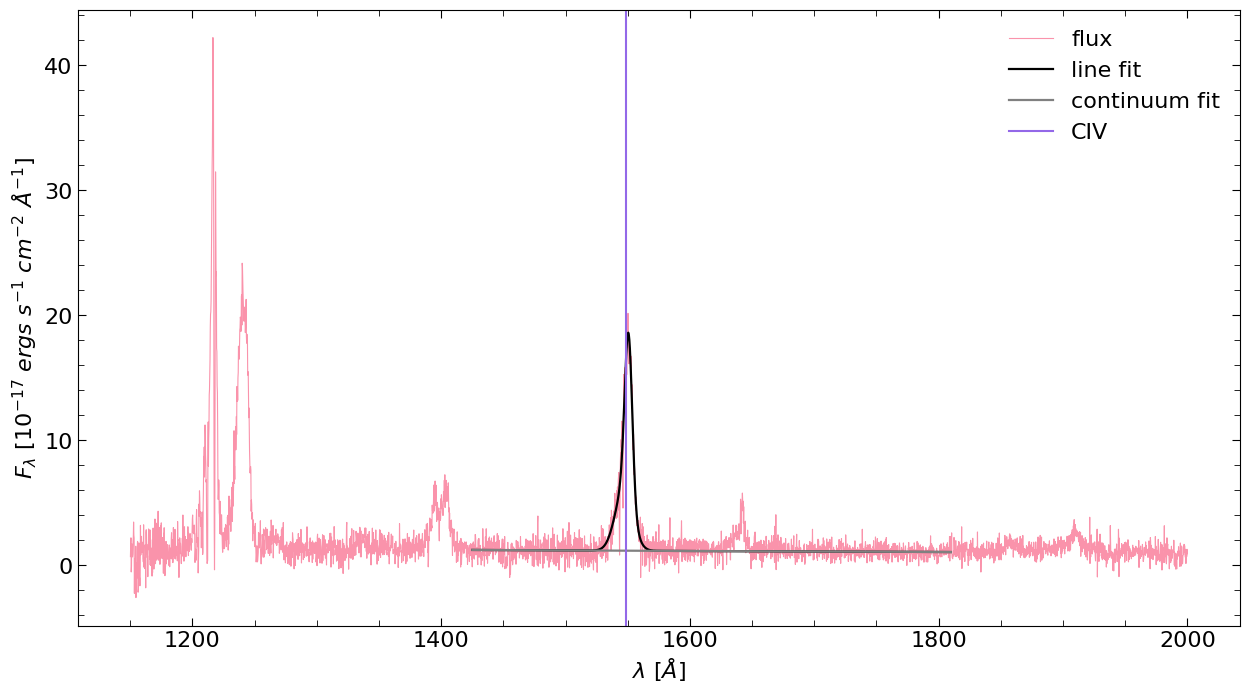


                SDSS: 233636.99+065231.0, DESI: 39627959455190480
                FWHM: 1648.623 vs 1483.559 (Hamann)
                REW: 183.7 vs 128.271 (Hamann)
                kt80: 0.292 vs 0.258 (Hamann)
                flux: 185.524 vs 215.999 (DESI)
    
---------------------------------------
---------------------------------------


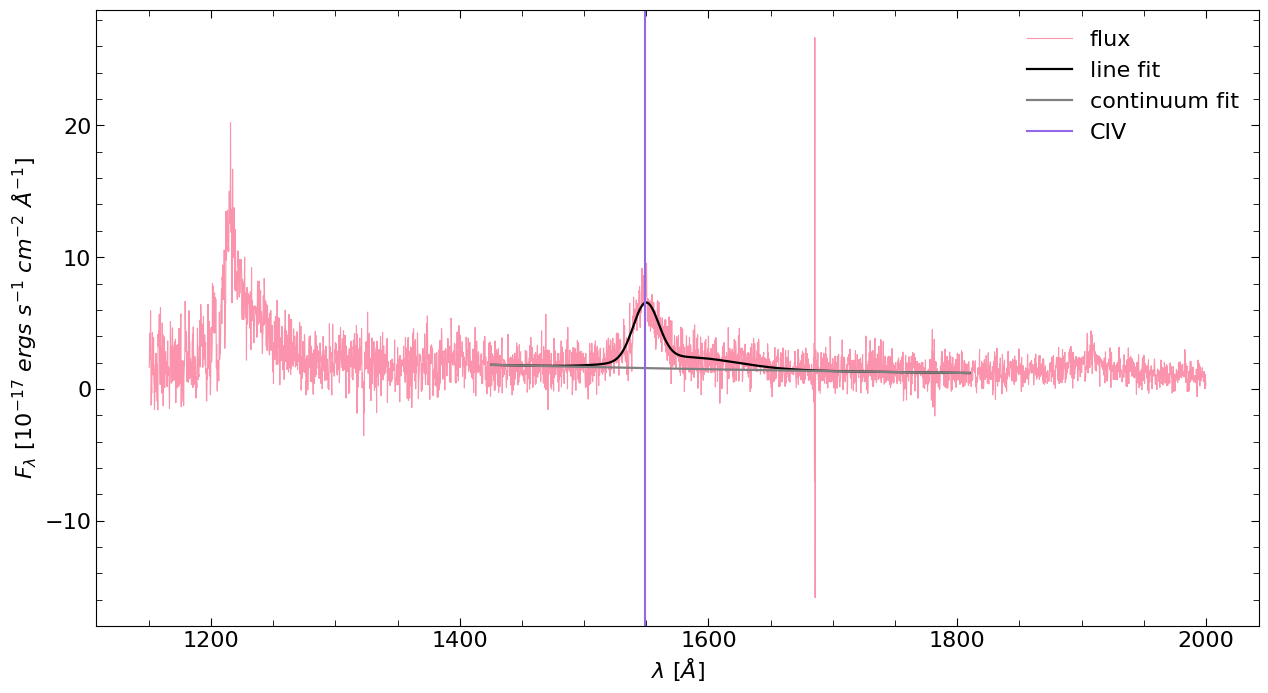


                SDSS: 082649.30+163945.2, DESI: 39628186186682006
                FWHM: 5194.551 vs 5633.199 (Hamann)
                REW: 130.126 vs 204.888 (Hamann)
                kt80: 0.308 vs 0.33 (Hamann)
                flux: 202.719 vs 182.182 (DESI)
    
---------------------------------------
---------------------------------------


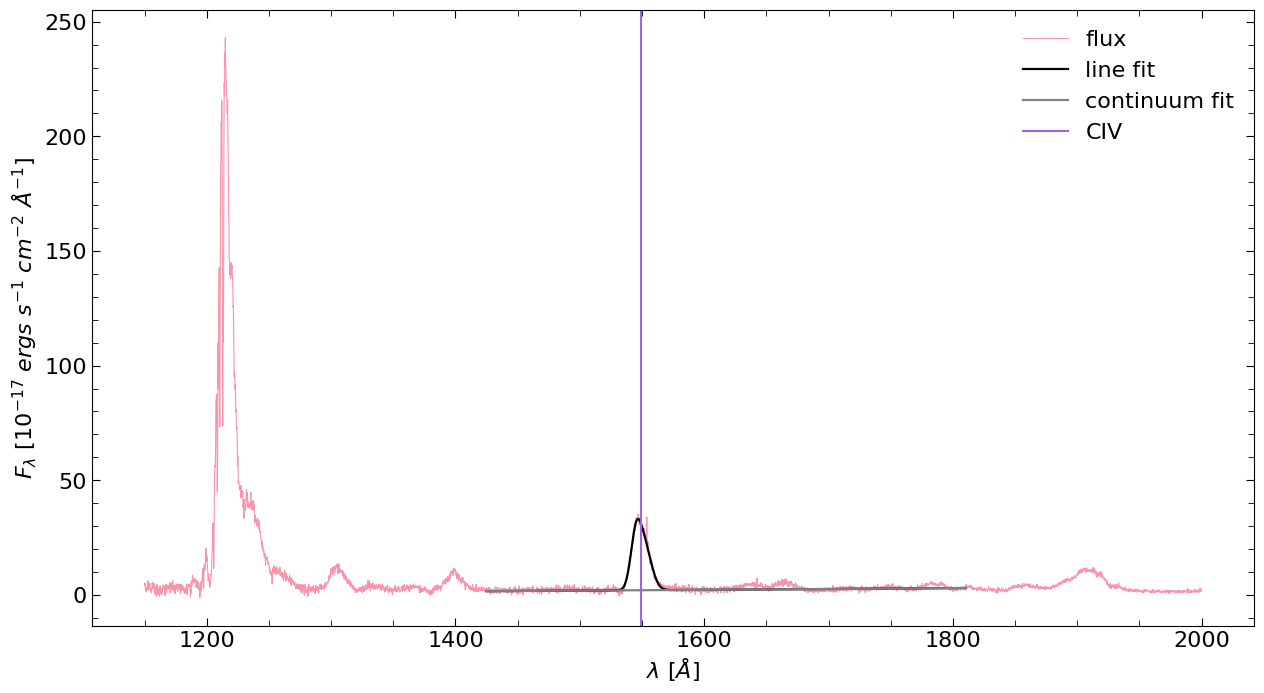


                SDSS: 083448.48+015921.1, DESI: 39627835203130381
                FWHM: 2890.433 vs 2863.092 (Hamann)
                REW: 284.012 vs 209.44 (Hamann)
                kt80: 0.366 vs 0.365 (Hamann)
                flux: 484.107 vs 549.36 (DESI)
    
---------------------------------------
---------------------------------------


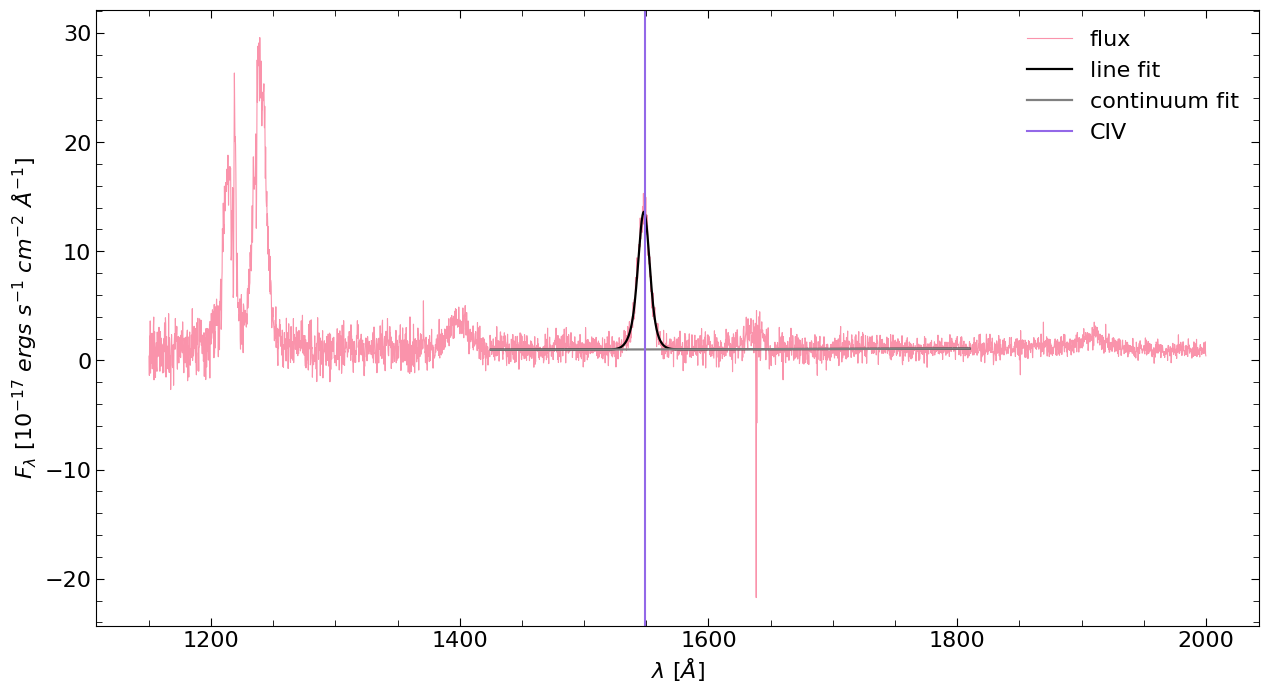


                SDSS: 131722.85+322207.5, DESI: 39628527628192559
                FWHM: 2206.497 vs 2310.771 (Hamann)
                REW: 202.788 vs 159.85 (Hamann)
                kt80: 0.339 vs 0.36 (Hamann)
                flux: 163.121 vs 169.607 (DESI)
    
---------------------------------------
---------------------------------------


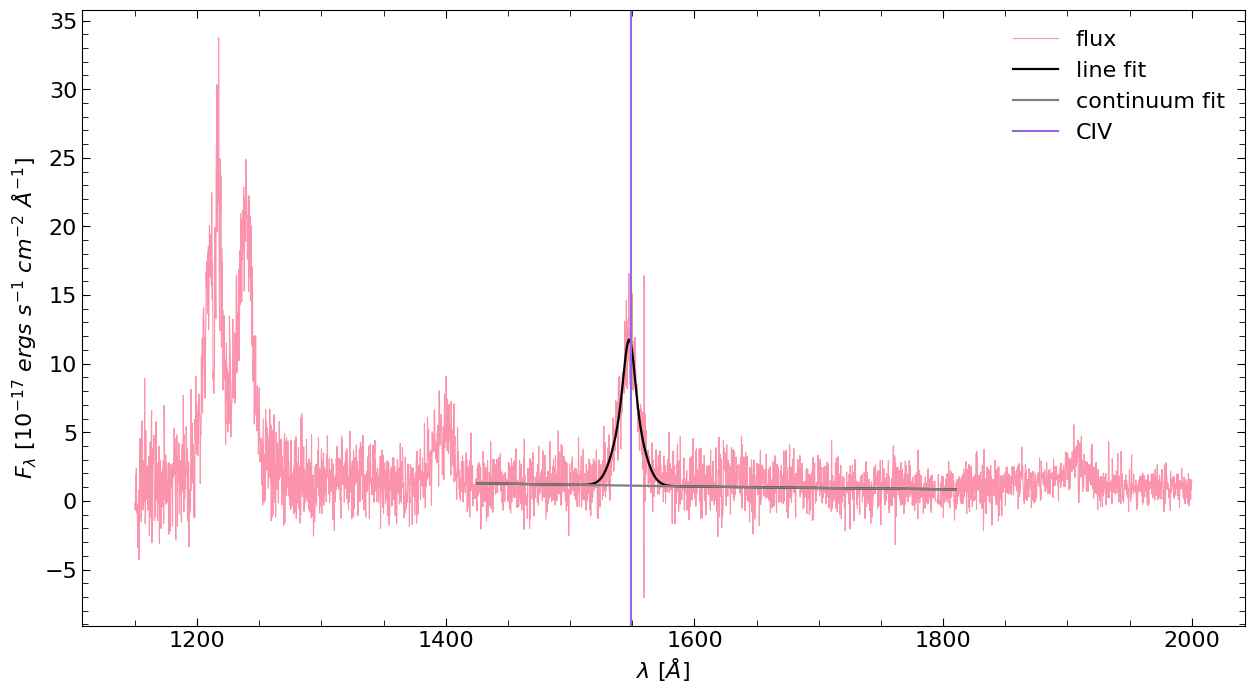


                SDSS: 130936.14+560111.3, DESI: 39633335785357580
                FWHM: 2985.714 vs 3629.606 (Hamann)
                REW: 207.821 vs 160.873 (Hamann)
                kt80: 0.272 vs 0.361 (Hamann)
                flux: 201.188 vs 224.631 (DESI)
    
---------------------------------------
---------------------------------------


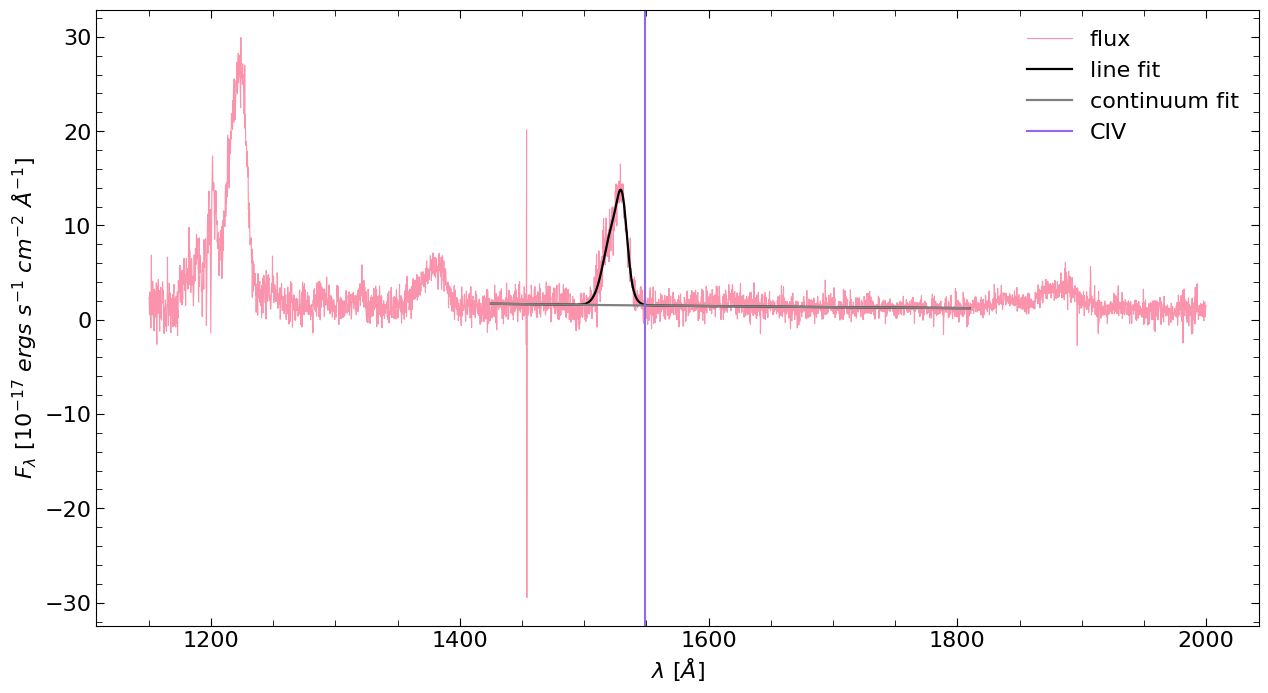


                SDSS: 002400.25+245031.9, DESI: 39628365275075274
                FWHM: 3367.331 vs 3523.282 (Hamann)
                REW: 149.974 vs 143.69 (Hamann)
                kt80: 0.314 vs 0.372 (Hamann)
                flux: 222.758 vs 25.127 (DESI)
    
---------------------------------------
---------------------------------------


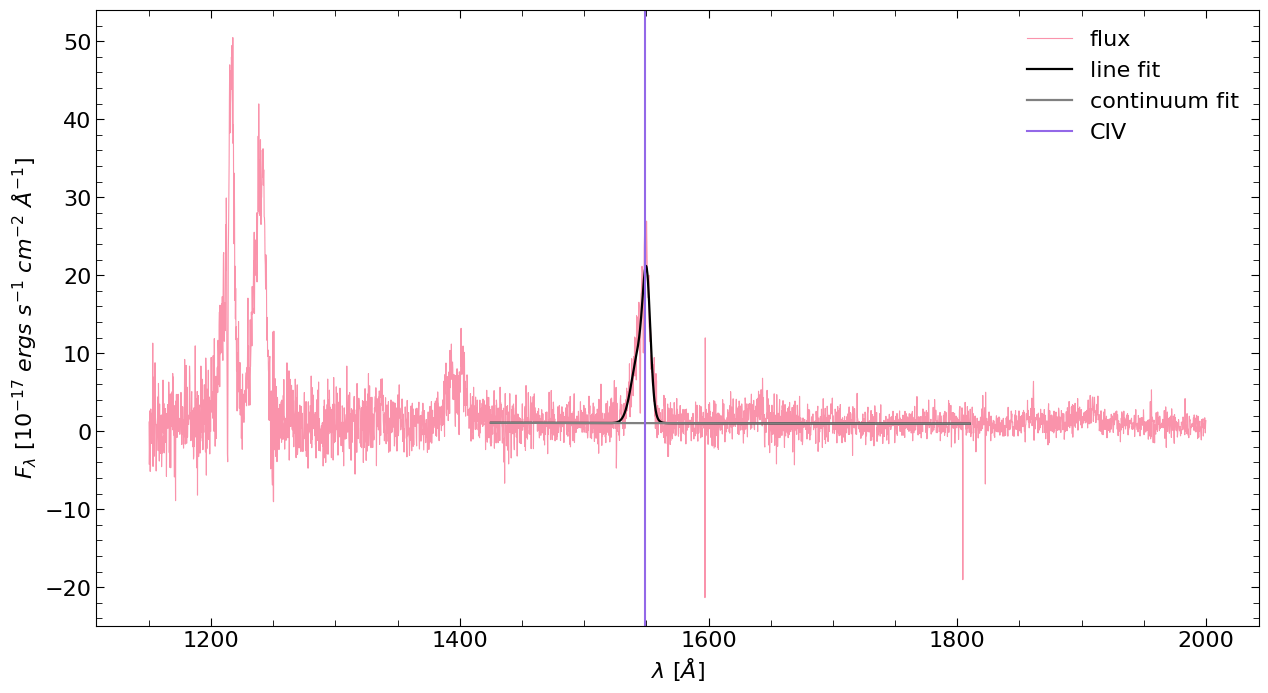


                SDSS: 134026.99+083427.2, DESI: 39627992917347231
                FWHM: 1999.276 vs 2075.846 (Hamann)
                REW: 288.218 vs 357.973 (Hamann)
                kt80: 0.263 vs 0.345 (Hamann)
                flux: 247.515 vs 251.394 (DESI)
    
---------------------------------------
---------------------------------------


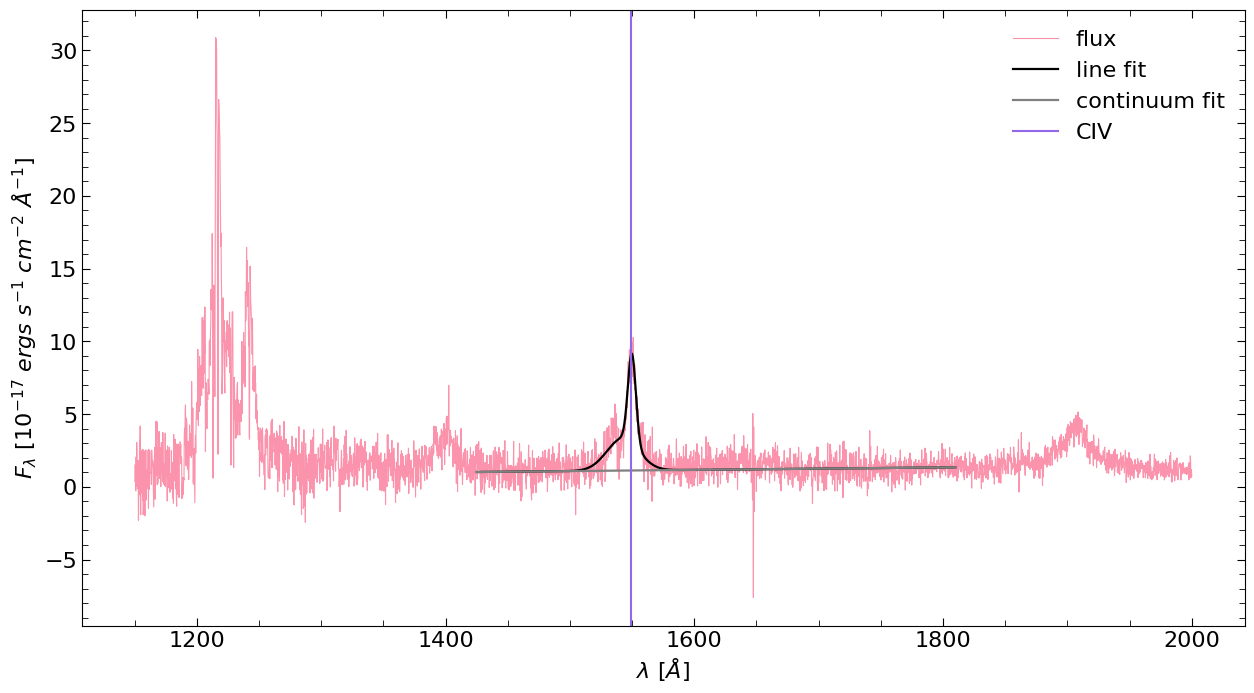


                SDSS: 134001.90+322155.9, DESI: 39628527707885249
                FWHM: 1791.316 vs 1822.703 (Hamann)
                REW: 132.411 vs 130.709 (Hamann)
                kt80: 0.199 vs 0.207 (Hamann)
                flux: 122.052 vs 92.811 (DESI)
    
---------------------------------------
---------------------------------------


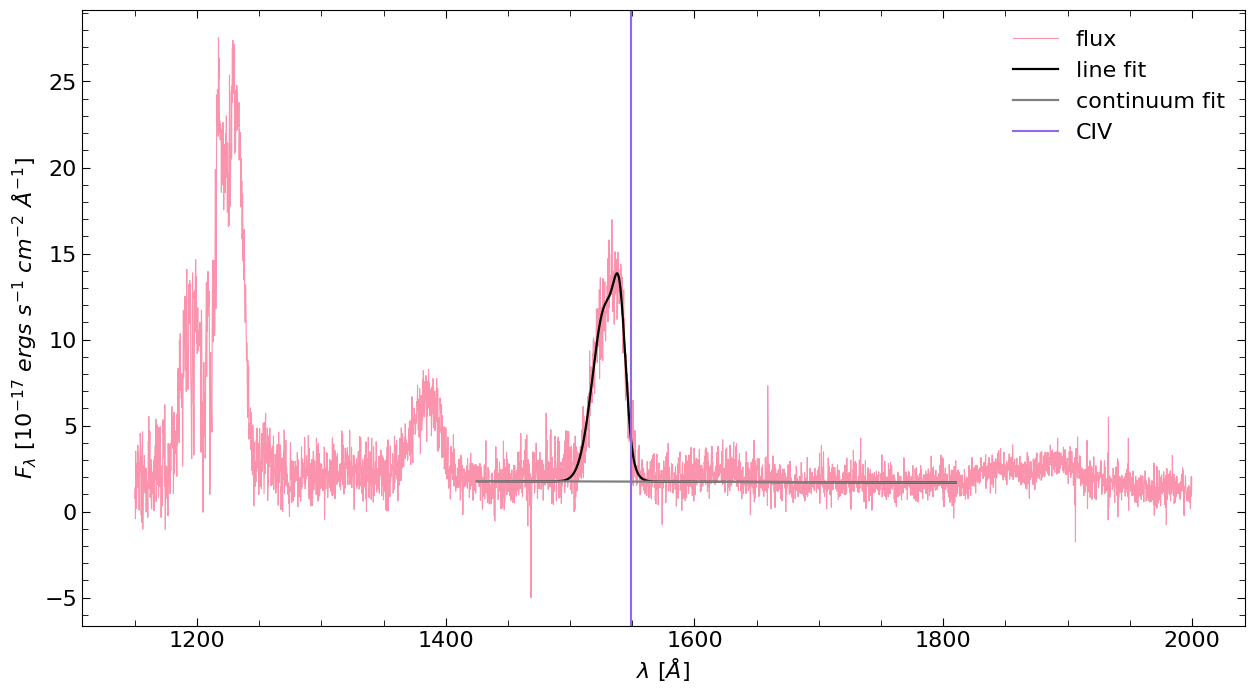


                SDSS: 104611.50+024351.6, DESI: 39627853876167561
                FWHM: 5282.471 vs 4854.269 (Hamann)
                REW: 222.267 vs 217.582 (Hamann)
                kt80: 0.444 vs 0.354 (Hamann)
                flux: 334.548 vs 255.654 (DESI)
    
---------------------------------------
---------------------------------------


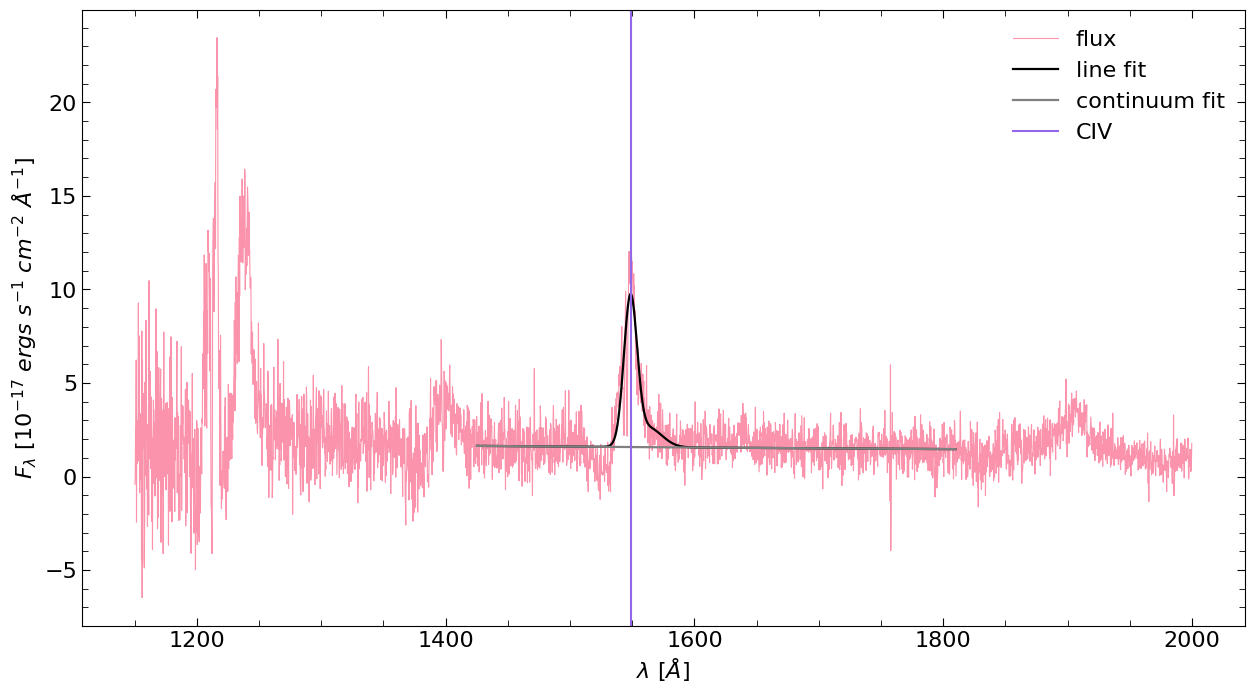


                SDSS: 093506.96-024137.7, DESI: 39627720702820887
                FWHM: 2536.696 vs 2404.04 (Hamann)
                REW: 86.859 vs 119.496 (Hamann)
                kt80: 0.344 vs 0.249 (Hamann)
                flux: 132.613 vs 147.833 (DESI)
    
---------------------------------------
---------------------------------------


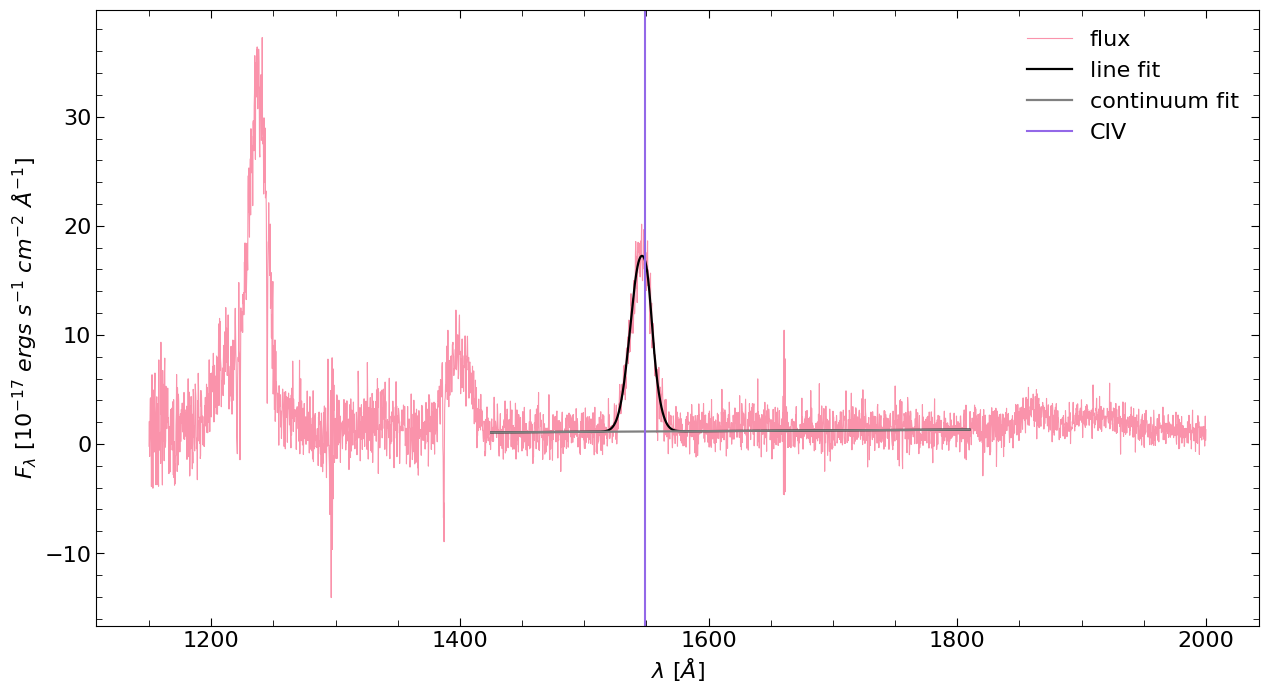


                SDSS: 232326.17-010033.1, DESI: 39627766454292268
                FWHM: 3892.044 vs 3989.27 (Hamann)
                REW: 327.085 vs 255.993 (Hamann)
                kt80: 0.41 vs 0.371 (Hamann)
                flux: 346.364 vs 374.365 (DESI)
    
---------------------------------------
---------------------------------------


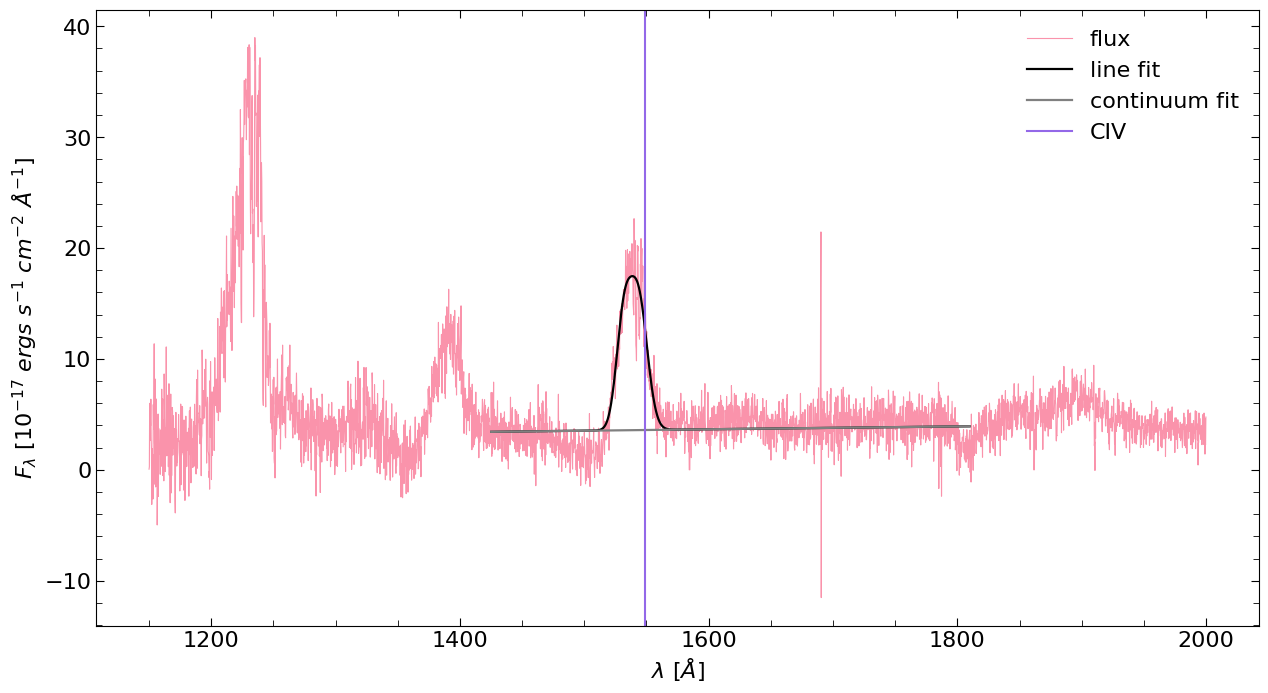


                SDSS: 103146.53+290324.1, DESI: 39628459336535305
                FWHM: 4765.365 vs 4363.774 (Hamann)
                REW: 91.133 vs 120.767 (Hamann)
                kt80: 0.484 vs 0.372 (Hamann)
                flux: 348.575 vs 321.487 (DESI)
    
---------------------------------------
---------------------------------------


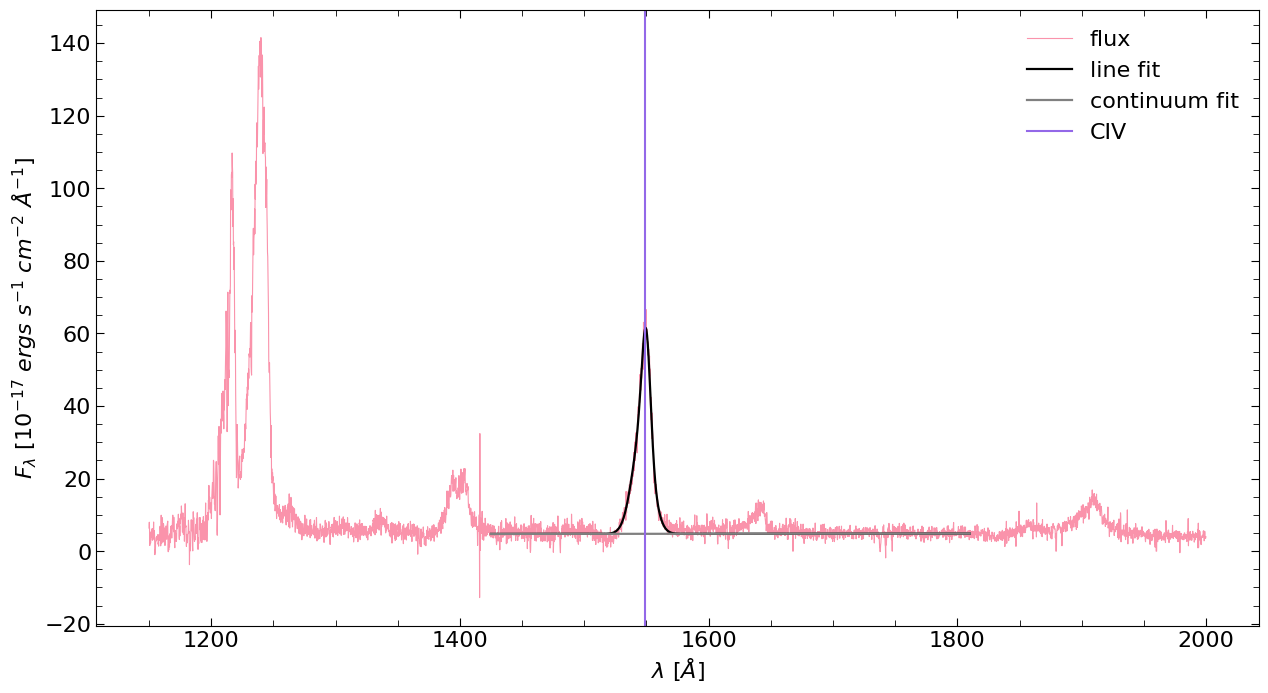


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2288.998 vs 2403.322 (Hamann)
                REW: 207.47 vs 124.521 (Hamann)
                kt80: 0.279 vs 0.329 (Hamann)
                flux: 808.359 vs 905.182 (DESI)
    
---------------------------------------
---------------------------------------


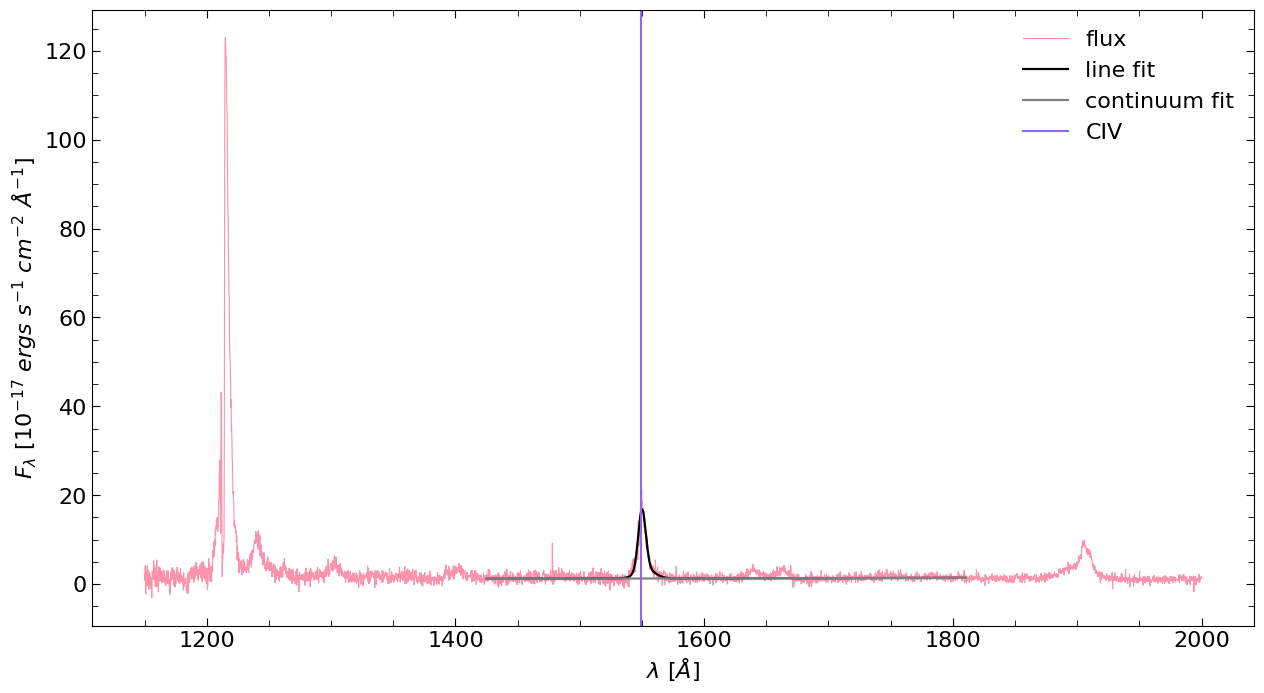


                SDSS: 122000.68+064045.3, DESI: 39627950634570587
                FWHM: 1483.541 vs 1047.131 (Hamann)
                REW: 152.564 vs 112.877 (Hamann)
                kt80: 0.345 vs 0.151 (Hamann)
                flux: 141.707 vs 137.558 (DESI)
    
---------------------------------------
---------------------------------------


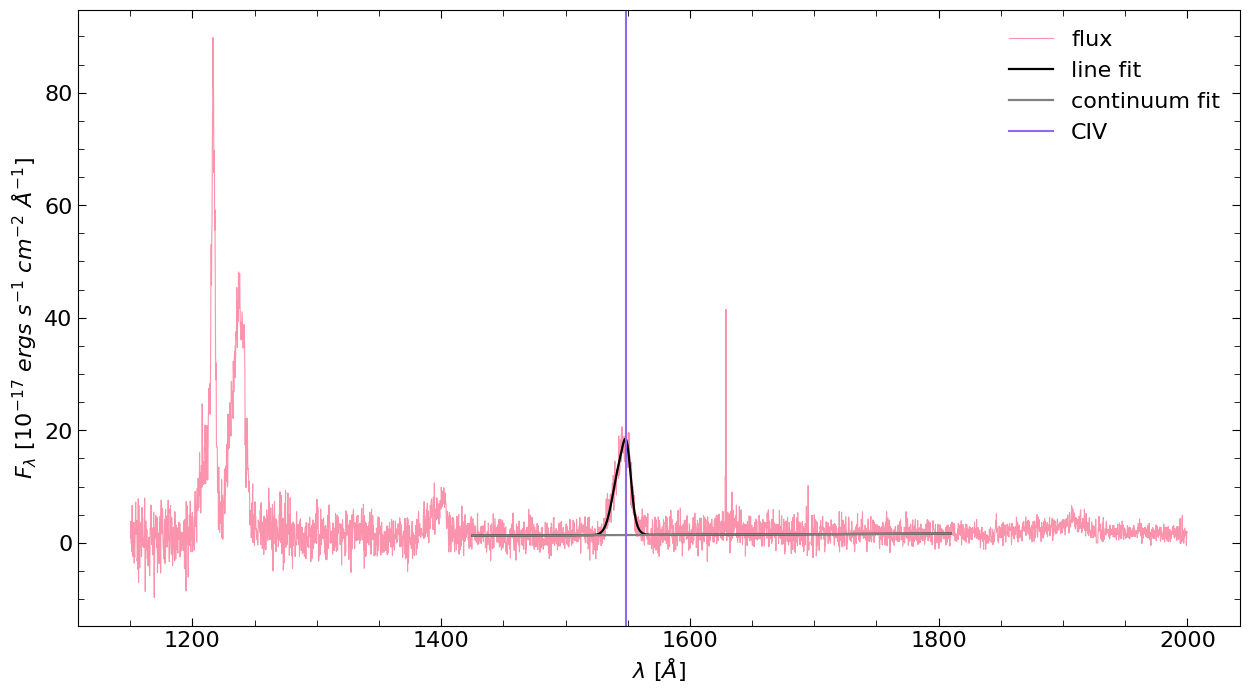


                SDSS: 121704.70+023417.1, DESI: 39627848218050974
                FWHM: 2727.075 vs 2603.968 (Hamann)
                REW: 214.919 vs 180.897 (Hamann)
                kt80: 0.34 vs 0.369 (Hamann)
                flux: 252.859 vs 281.832 (DESI)
    
---------------------------------------
---------------------------------------


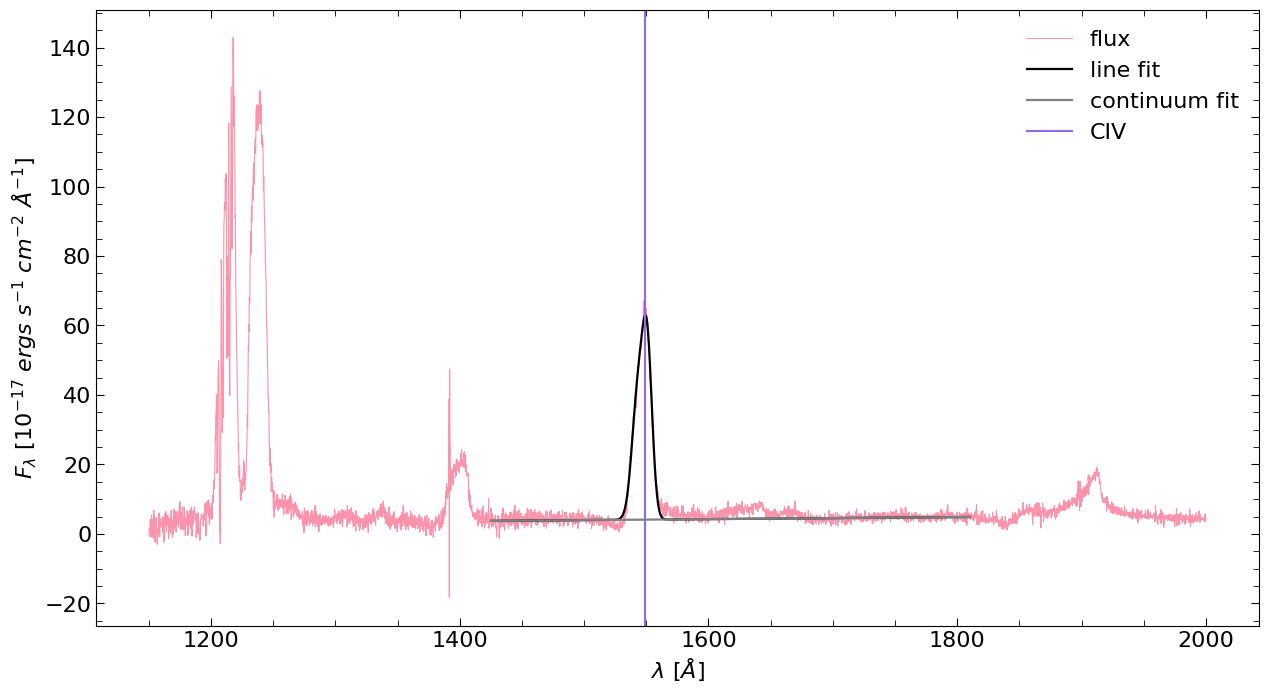


                SDSS: 131047.78+322518.3, DESI: 39632930762395245
                FWHM: 2863.763 vs 2793.839 (Hamann)
                REW: 258.295 vs 226.394 (Hamann)
                kt80: 0.381 vs 0.367 (Hamann)
                flux: 884.277 vs 925.713 (DESI)
    
---------------------------------------
---------------------------------------


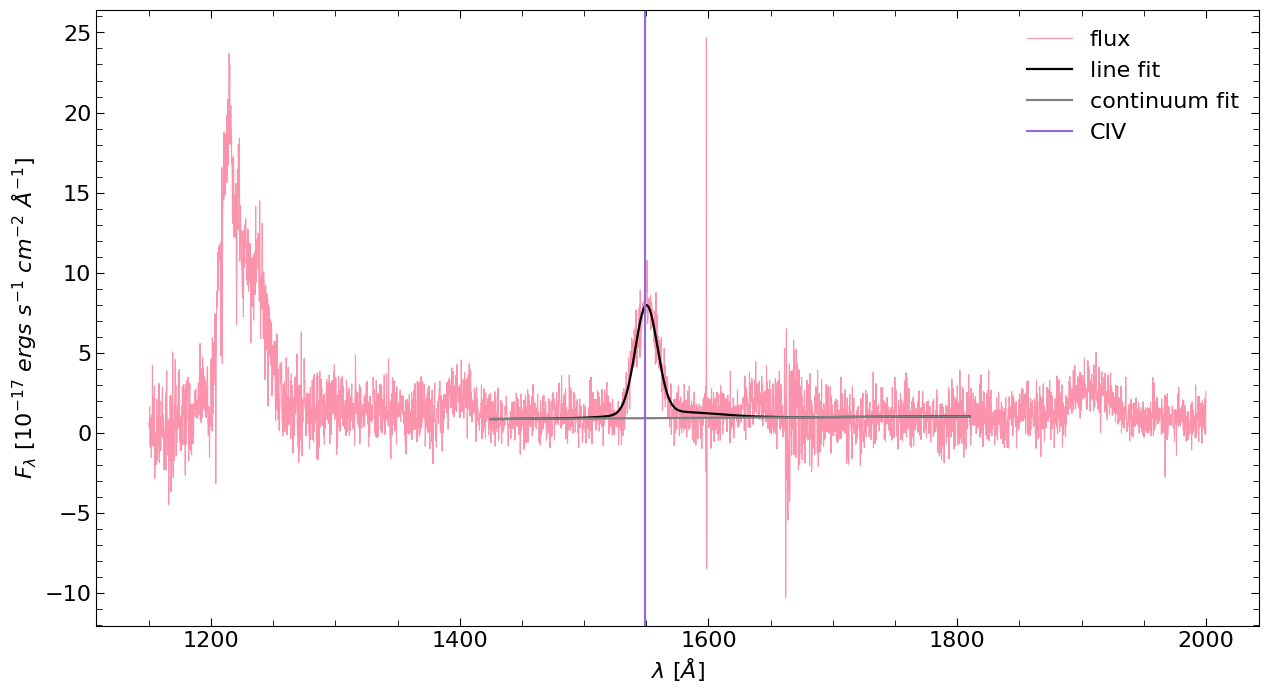


                SDSS: 221524.00-005643.8, DESI: 39627766169079016
                FWHM: 4179.381 vs 4280.102 (Hamann)
                REW: 240.952 vs 153.336 (Hamann)
                kt80: 0.361 vs 0.366 (Hamann)
                flux: 192.344 vs 272.195 (DESI)
    
---------------------------------------
---------------------------------------


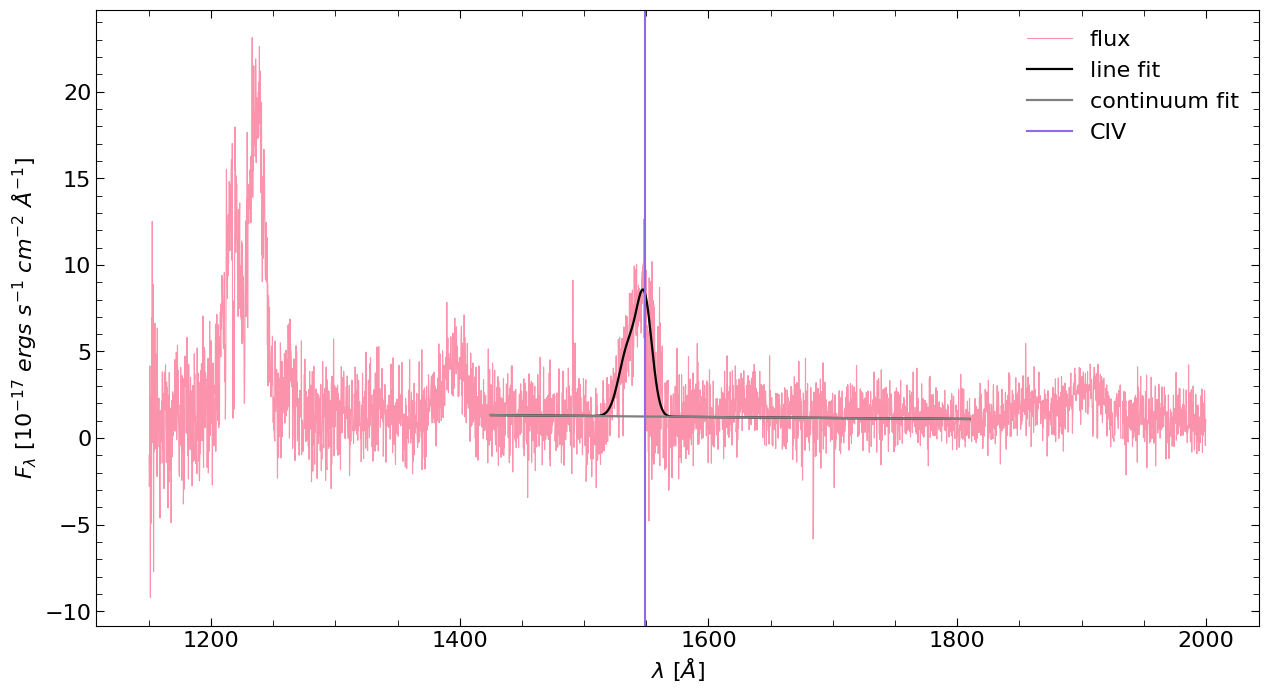


                SDSS: 134450.51+140139.2, DESI: 39628123335037135
                FWHM: 4426.843 vs 4487.034 (Hamann)
                REW: 136.008 vs 132.41 (Hamann)
                kt80: 0.316 vs 0.372 (Hamann)
                flux: 158.997 vs 179.483 (DESI)
    
---------------------------------------
---------------------------------------


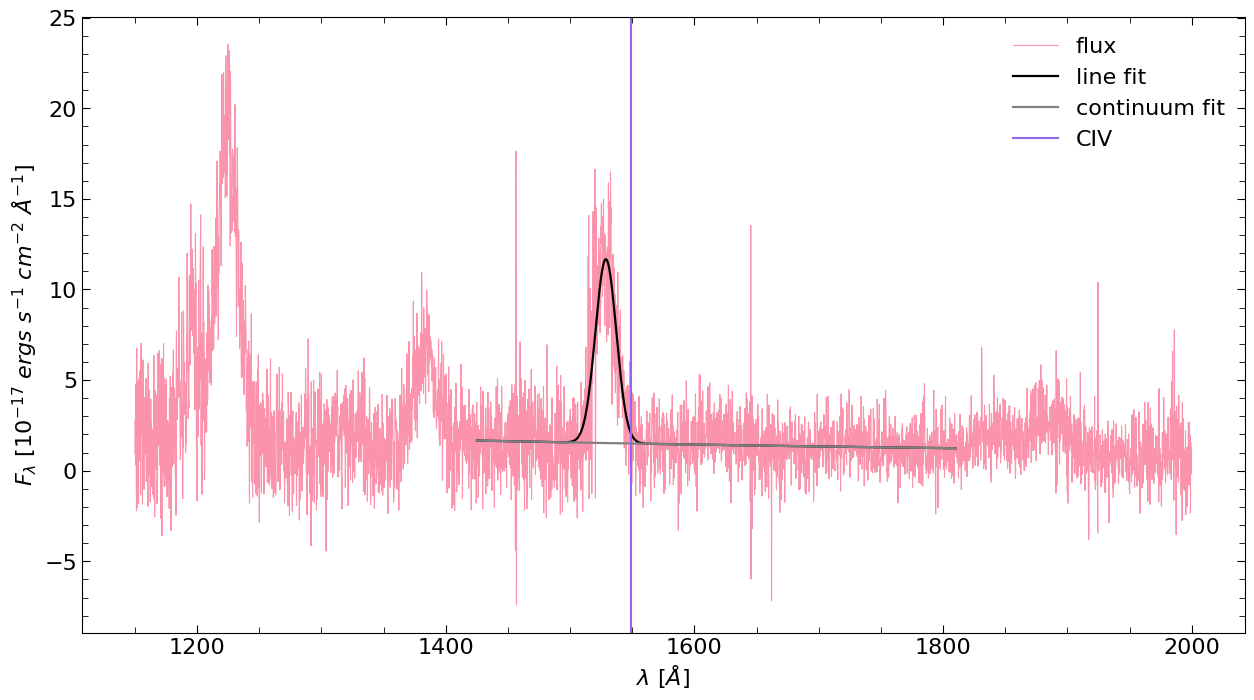


                SDSS: 153107.14+105825.8, DESI: 39628052950420499
                FWHM: 3825.968 vs 3936.554 (Hamann)
                REW: 151.518 vs 151.904 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
                flux: 218.379 vs 1.086 (DESI)
    
---------------------------------------
---------------------------------------


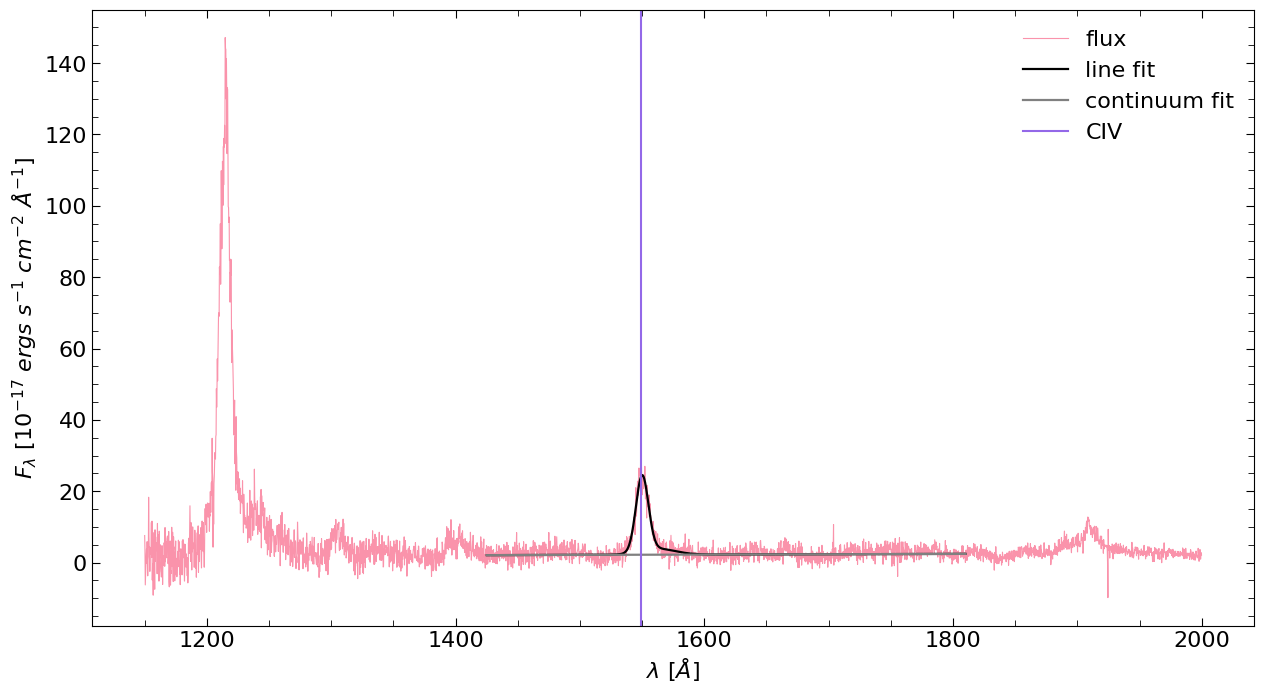


                SDSS: 104718.35+484433.8, DESI: 39633228125965823
                FWHM: 2358.505 vs 2521.46 (Hamann)
                REW: 165.28 vs 158.03 (Hamann)
                kt80: 0.358 vs 0.361 (Hamann)
                flux: 325.938 vs 310.697 (DESI)
    
---------------------------------------
---------------------------------------


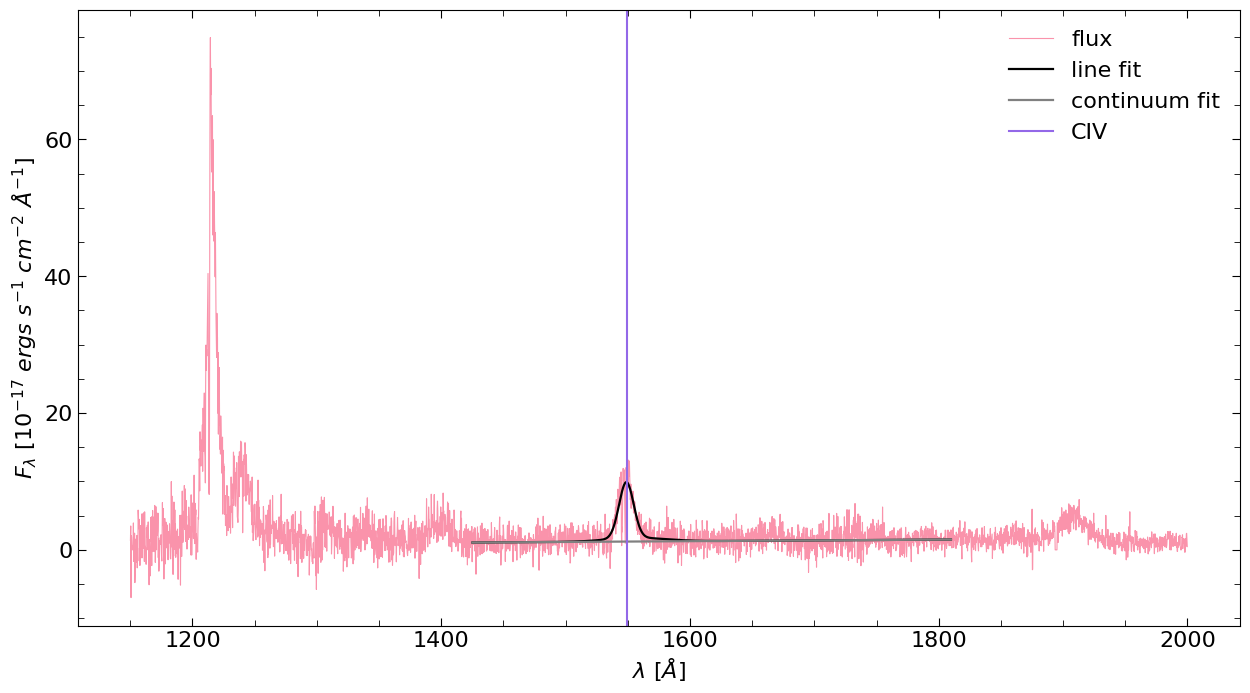


                SDSS: 020932.15+312202.7, DESI: 39628504643403849
                FWHM: 2776.931 vs 2180.064 (Hamann)
                REW: 142.815 vs 107.677 (Hamann)
                kt80: 0.358 vs 0.345 (Hamann)
                flux: 149.201 vs 160.998 (DESI)
    
---------------------------------------
---------------------------------------


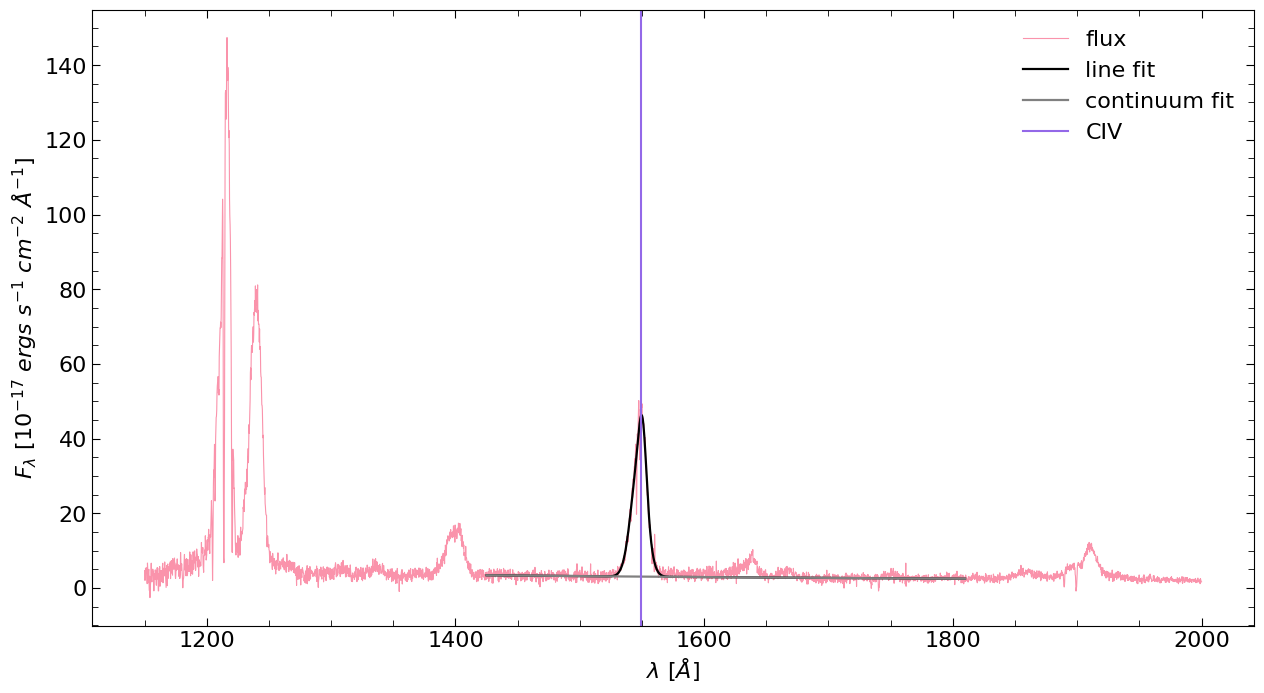


                SDSS: 082653.42+054247.3, DESI: 39627925623935704
                FWHM: 2383.407 vs 2433.822 (Hamann)
                REW: 235.668 vs 204.619 (Hamann)
                kt80: 0.313 vs 0.358 (Hamann)
                flux: 588.126 vs 624.157 (DESI)
    
---------------------------------------
---------------------------------------


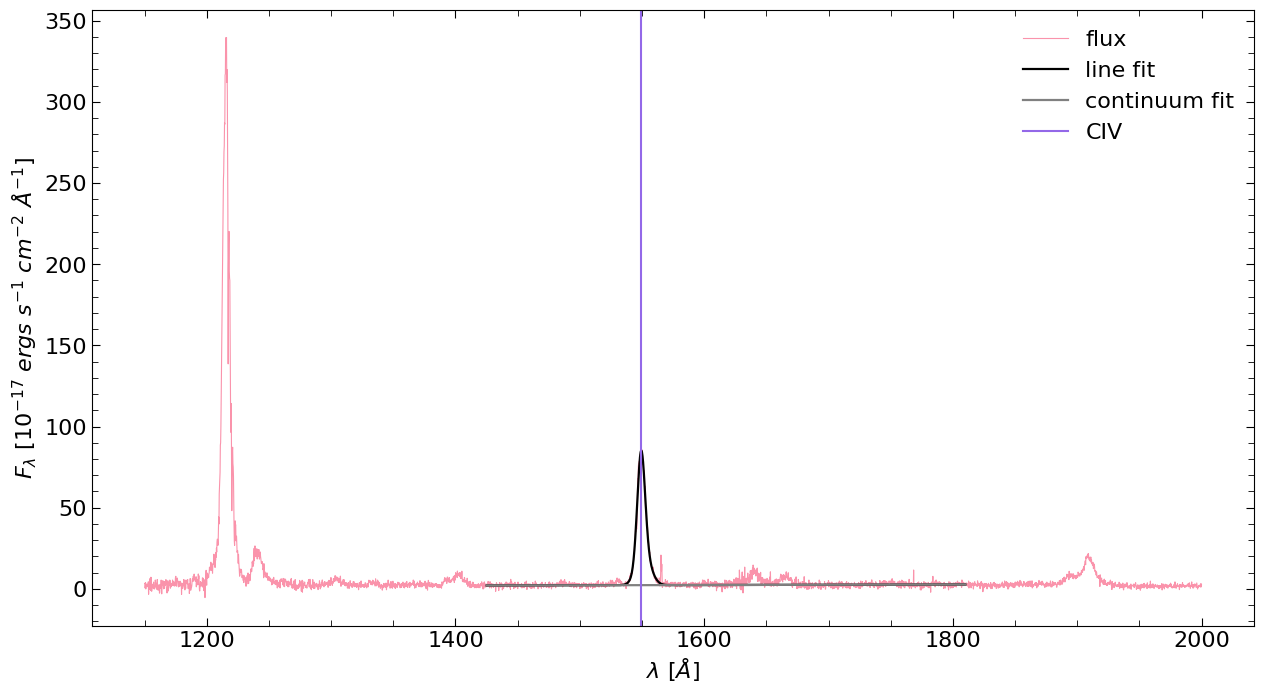


                SDSS: 232828.47+044346.8, DESI: 39627905315113841
                FWHM: 1566.323 vs 1583.693 (Hamann)
                REW: 400.885 vs 358.596 (Hamann)
                kt80: 0.342 vs 0.352 (Hamann)
                flux: 764.171 vs 882.327 (DESI)
    
---------------------------------------
---------------------------------------


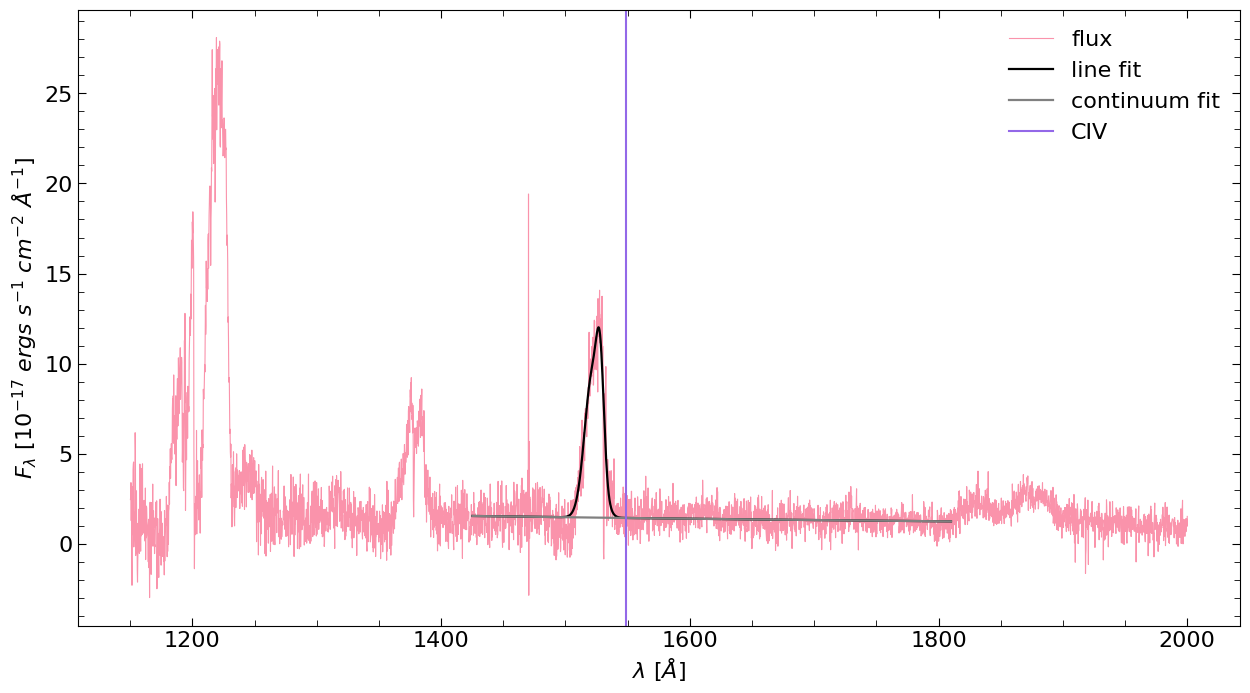


                SDSS: 154831.92+311951.4, DESI: 39628507583615618
                FWHM: 2962.141 vs 3050.048 (Hamann)
                REW: 122.442 vs 127.184 (Hamann)
                kt80: 0.353 vs 0.372 (Hamann)
                flux: 163.205 vs 3.494 (DESI)
    
---------------------------------------
---------------------------------------


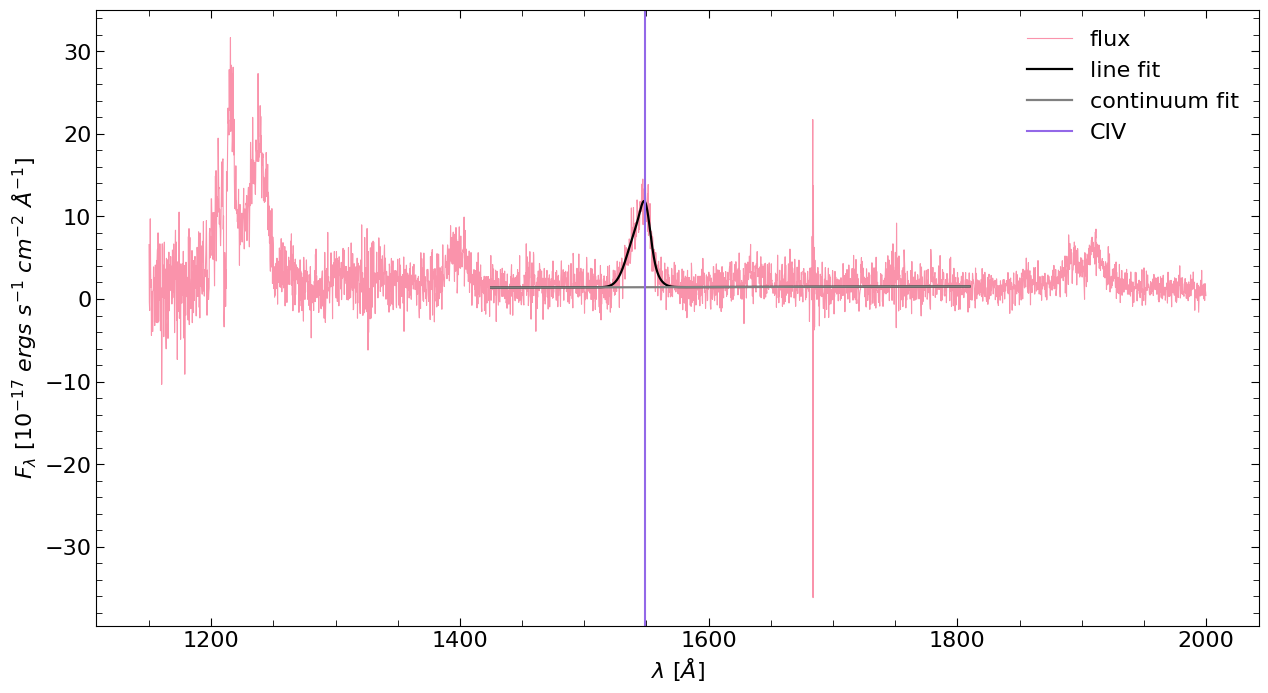


                SDSS: 080547.66+454159.0, DESI: 39633178285048118
                FWHM: 3351.589 vs 2667.071 (Hamann)
                REW: 175.053 vs 108.69 (Hamann)
                kt80: 0.297 vs 0.211 (Hamann)
                flux: 194.368 vs 242.485 (DESI)
    
---------------------------------------
---------------------------------------


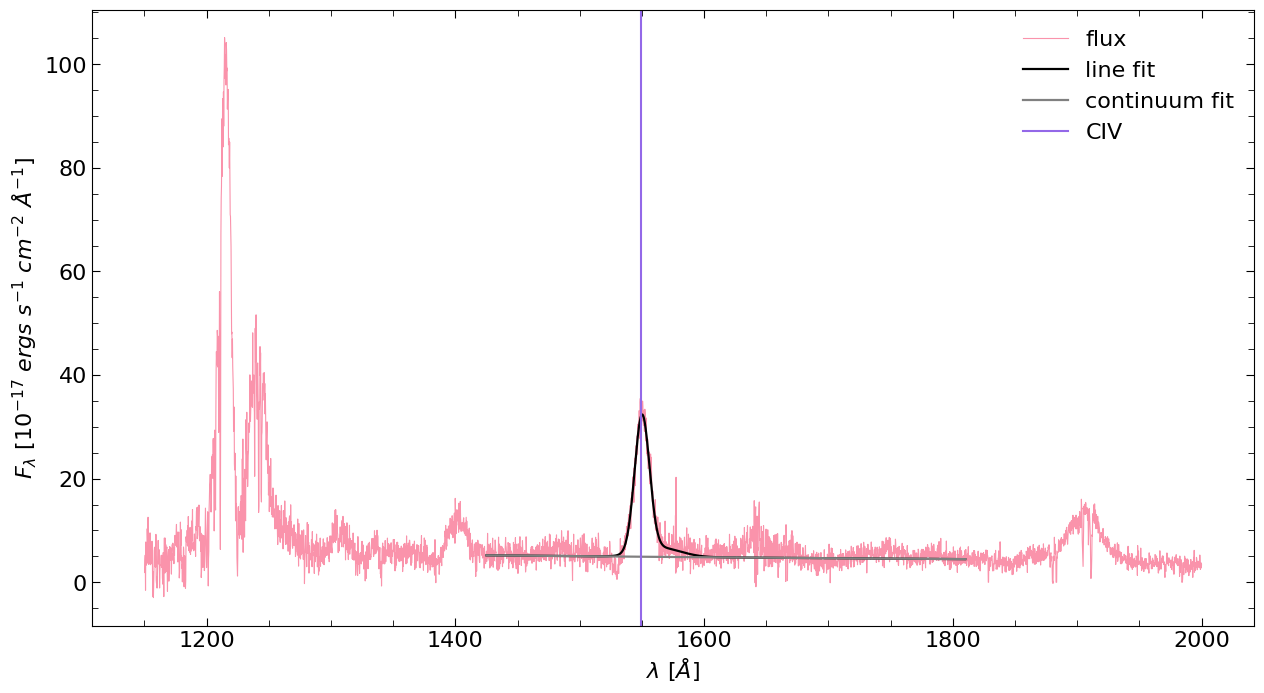


                SDSS: 014111.13-031852.5, DESI: 39627706643513715
                FWHM: 2807.247 vs 2985.648 (Hamann)
                REW: 118.8 vs 101.008 (Hamann)
                kt80: 0.361 vs 0.372 (Hamann)
                flux: 461.012 vs 436.53 (DESI)
    
---------------------------------------
---------------------------------------


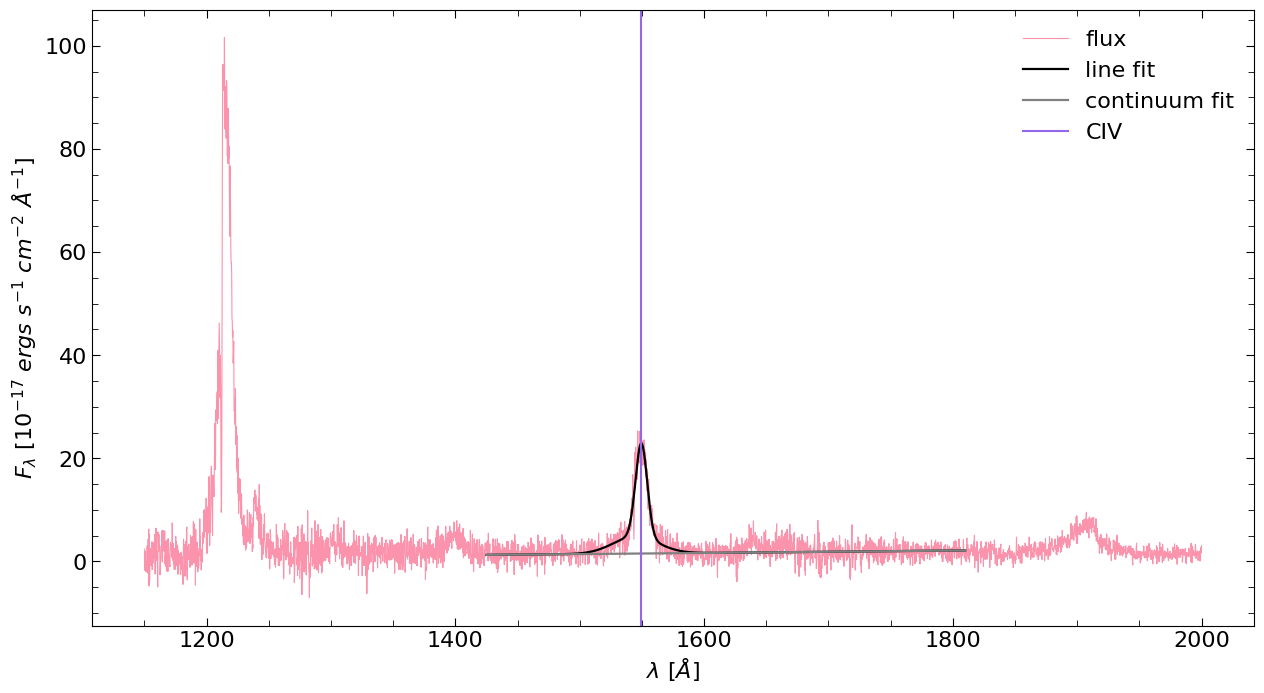


                SDSS: 000746.19+122223.9, DESI: 39628078770555722
                FWHM: 2384.728 vs 2432.83 (Hamann)
                REW: 265.526 vs 219.634 (Hamann)
                kt80: 0.325 vs 0.284 (Hamann)
                flux: 359.793 vs 382.848 (DESI)
    
---------------------------------------
---------------------------------------


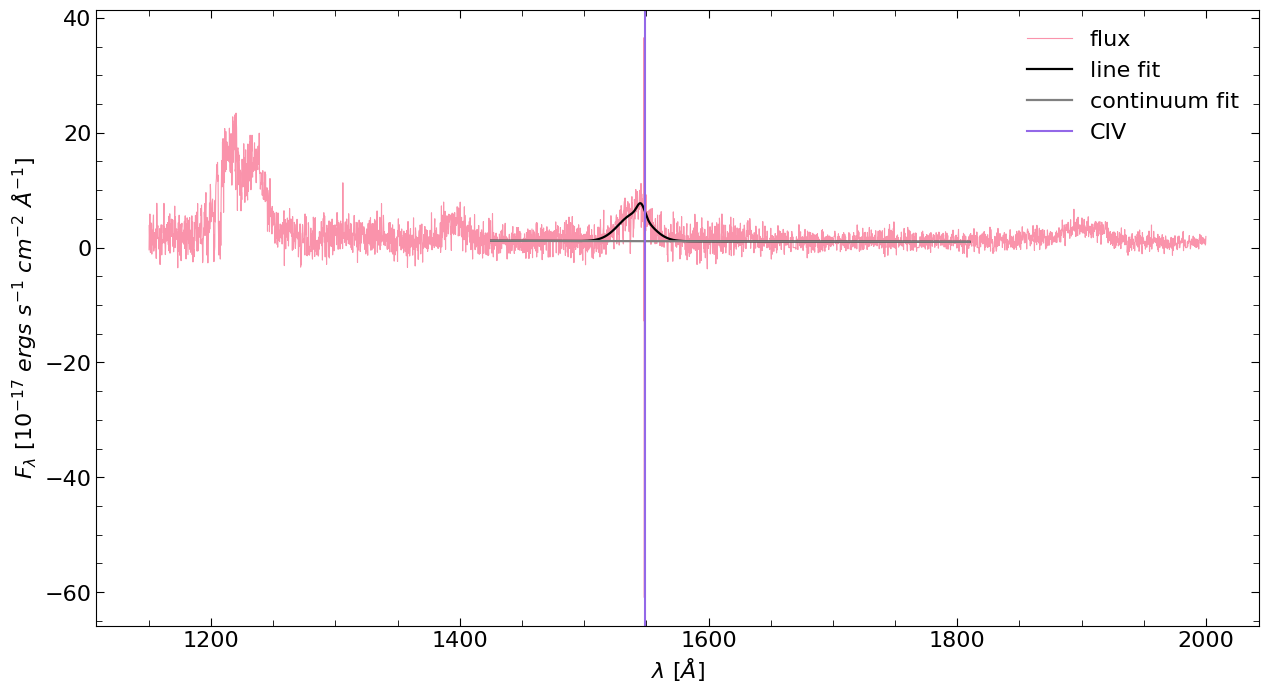


                SDSS: 085451.11+173009.1, DESI: 39628203643371939
                FWHM: 4365.706 vs 4199.357 (Hamann)
                REW: 178.738 vs 120.014 (Hamann)
                kt80: 0.204 vs 0.37 (Hamann)
                flux: 164.191 vs 223.233 (DESI)
    
---------------------------------------
---------------------------------------


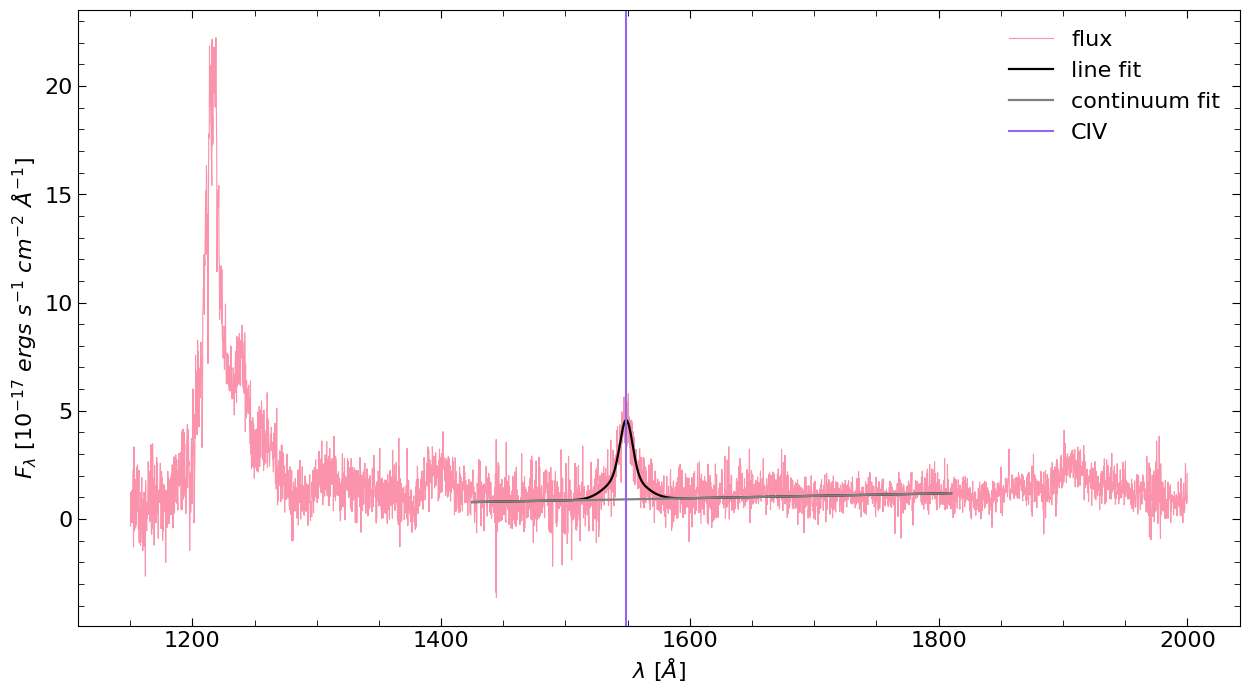


                SDSS: 102447.32-013633.8, DESI: 39627751107334558
                FWHM: 2832.346 vs 2843.202 (Hamann)
                REW: 90.681 vs 192.349 (Hamann)
                kt80: 0.282 vs 0.148 (Hamann)
                flux: 70.223 vs 90.278 (DESI)
    
---------------------------------------
---------------------------------------


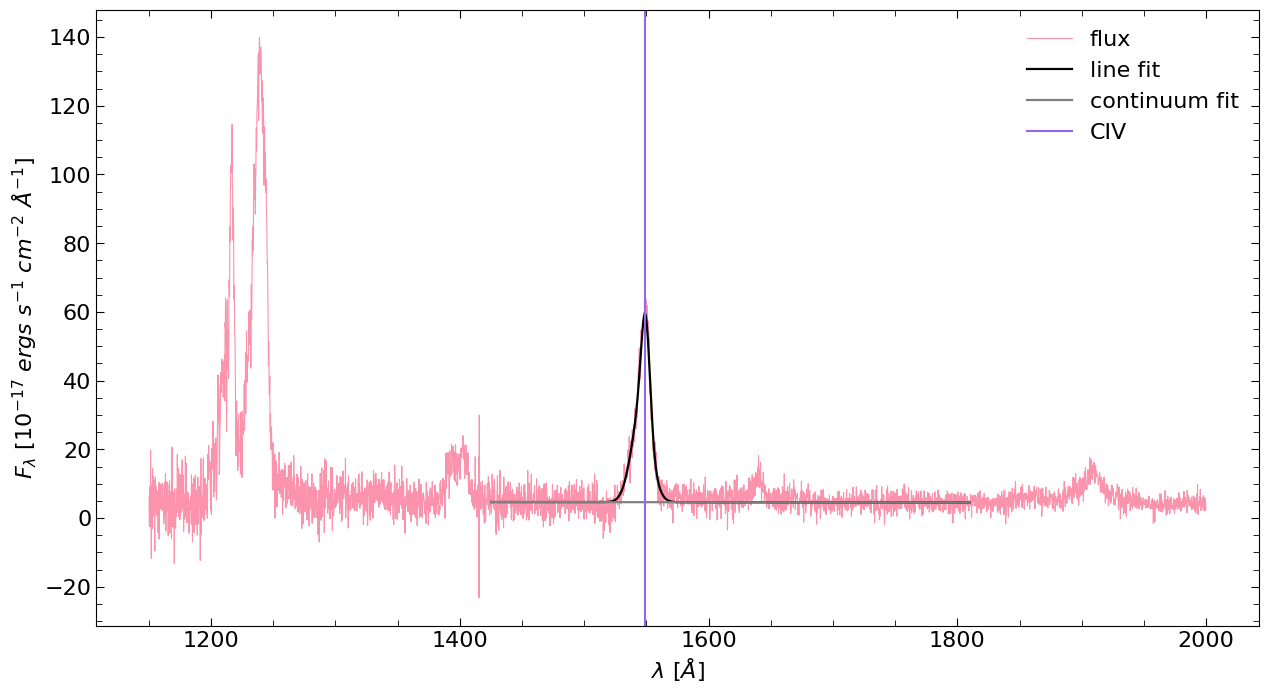


                SDSS: 165202.64+172852.3, DESI: 39628205555974657
                FWHM: 2308.115 vs 2403.322 (Hamann)
                REW: 197.233 vs 124.521 (Hamann)
                kt80: 0.283 vs 0.329 (Hamann)
                flux: 782.11 vs 905.182 (DESI)
    


In [15]:
for i in range(len(spectra_df)):
    if spectra_df["specid"][i] in valid_idxs:
        print("---------------------------------------\n---------------------------------------")
        sanity_tests(i)